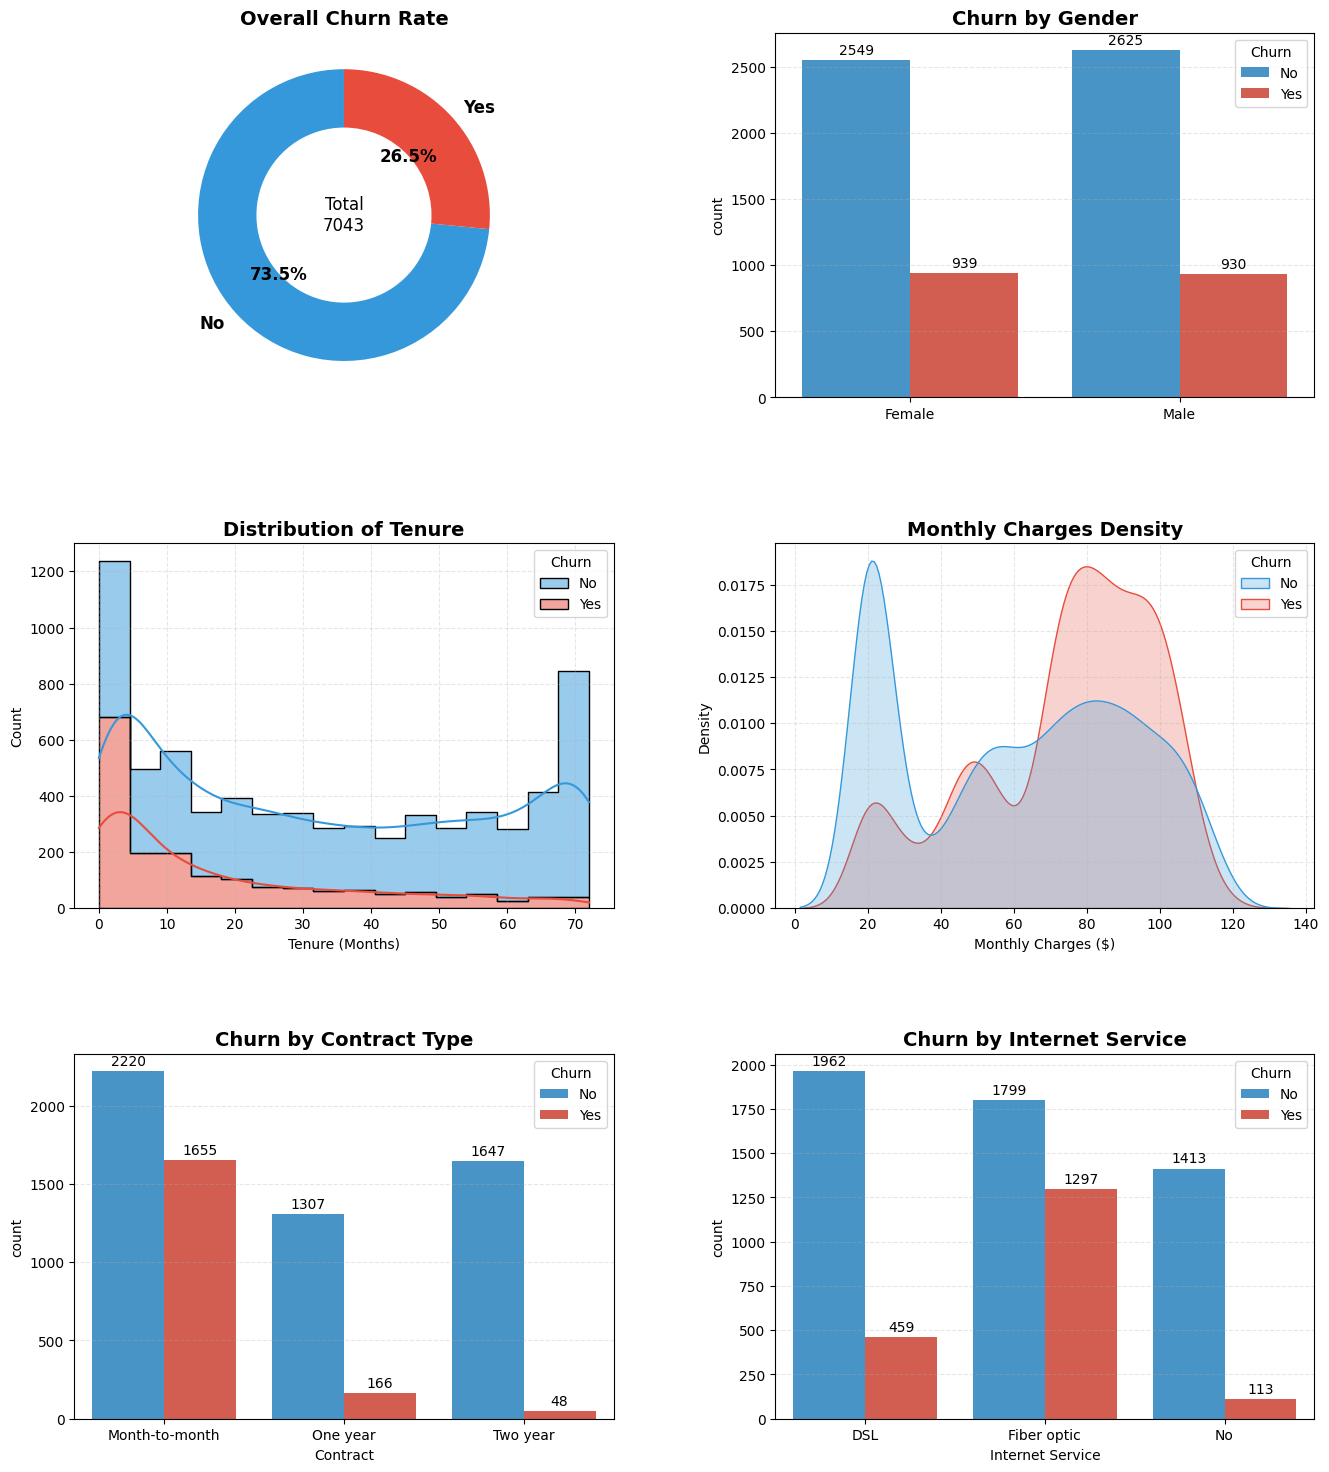

In [1]:
# ==========================================
# PHẦN 1: CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


# ==========================================
# 1. CẤU HÌNH GIAO DIỆN & MÀU SẮC
# ==========================================
# Reset về mặc định để tránh lỗi font
plt.style.use('default') 

# Cấu hình Grid
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['figure.figsize'] = (16, 18) # Kích thước lớn cho 6 biểu đồ
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# ĐỊNH NGHĨA BẢNG MÀU ĐỒNG NHẤT
# Blue cho 'No' (An toàn), Red cho 'Yes' (Cảnh báo)
# Sử dụng Hex codes chuẩn màu phẳng (Flat UI Colors) cho đẹp
custom_palette = {'No': '#3498DB', 'Yes': '#E74C3C'} 
custom_colors = ['#3498DB', '#E74C3C'] # Dùng cho Pie chart

# ==========================================
# 2. KHỞI TẠO KHUNG VẼ (3 Hàng x 2 Cột)
# ==========================================
fig, axes = plt.subplots(3, 2)
plt.subplots_adjust(hspace=0.4, wspace=0.3) # Khoảng cách giữa các chart

# Tiêu đề tổng
# fig.suptitle('EDA Dashboard: Phân tích các yếu tố ảnh hưởng đến Churn', fontsize=20, y=0.92)

# ==========================================
# CHART 1: Tỷ lệ Churn Tổng thể (Donut)
# ==========================================
try:
    df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
except:
    df = pd.read_csv('https://raw.githubusercontent.com/wafic/Telco-Customer-Churn/master/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Cleaning
churn_counts = df['Churn'].value_counts()
axes[0, 0].pie(
    churn_counts, 
    labels=churn_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=[custom_palette[key] for key in churn_counts.index], # Map đúng màu
    wedgeprops=dict(width=0.4),
    textprops={'fontsize': 12, 'weight': 'bold'}
)
axes[0, 0].set_title('Overall Churn Rate')
axes[0, 0].text(0, 0, f"Total\n{len(df)}", ha='center', va='center', fontsize=12)

# ==========================================
# CHART 2: Giới tính (Gender)
# ==========================================
sns.countplot(data=df, x='gender', hue='Churn', ax=axes[0, 1], palette=custom_palette)
axes[0, 1].set_title('Churn by Gender')
axes[0, 1].set_xlabel('')
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, padding=2)

# ==========================================
# CHART 3: Thời gian gắn bó (Tenure)
# ==========================================
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', 
             kde=True, ax=axes[1, 0], palette=custom_palette, element="step")
axes[1, 0].set_title('Distribution of Tenure')
axes[1, 0].set_xlabel('Tenure (Months)')

# ==========================================
# CHART 4: Cước phí hàng tháng (Monthly Charges)
# ==========================================
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, 
            common_norm=False, ax=axes[1, 1], palette=custom_palette)
axes[1, 1].set_title('Monthly Charges Density')
axes[1, 1].set_xlabel('Monthly Charges ($)')

# ==========================================
# CHART 5: Loại Hợp Đồng (Contract)
# ==========================================
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[2, 0], palette=custom_palette)
axes[2, 0].set_title('Churn by Contract Type')
axes[2, 0].set_xlabel('Contract')
for container in axes[2, 0].containers:
    axes[2, 0].bar_label(container, padding=2)

# ==========================================
# CHART 6: Dịch vụ Internet (Internet Service)
# ==========================================
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[2, 1], palette=custom_palette)
axes[2, 1].set_title('Churn by Internet Service')
axes[2, 1].set_xlabel('Internet Service')
for container in axes[2, 1].containers:
    axes[2, 1].bar_label(container, padding=2)

plt.savefig('Fig_09_EDA.png', dpi=300, bbox_inches='tight')
plt.show()

In [2]:
import plotly.express as px

# ==========================================
# PARALLEL CATEGORIES PLOT
# ==========================================

# 1. Chuẩn bị dữ liệu
df_plot = df.copy()

# Rút gọn tên PaymentMethod cho đẹp
df_plot['PaymentMethod'] = df_plot['PaymentMethod'].str.replace(' (automatic)', '', regex=False)

# --- BƯỚC QUAN TRỌNG ĐỂ FIX LỖI MÀU ---
# Chuyển đổi Churn thành số: No=0 (Xanh), Yes=1 (Đỏ) để dùng color_continuous_scale
df_plot['Churn_Value'] = df_plot['Churn'].map({'No': 0, 'Yes': 1})

# Sắp xếp để luồng màu vẽ đẹp hơn (đưa nhóm Yes lên trên)
df_plot = df_plot.sort_values(by='Churn_Value')

# 2. Vẽ biểu đồ
cols_to_plot = ['Contract', 'InternetService', 'PaymentMethod', 
                'InternetService', 'PaperlessBilling', 'Dependents', 'Churn']


fig = px.parallel_categories(
    df_plot,
    dimensions=cols_to_plot,
    color='Churn_Value', # Dùng cột số vừa tạo để tô màu
    # Ép màu: 0 là Xanh (#3498DB), 1 là Đỏ (#E74C3C)
    color_continuous_scale=[(0, '#3498DB'), (1, '#E74C3C')],
    labels={
        'Contract': 'Hợp Đồng',
        'InternetService': 'Internet',
        'PaymentMethod': 'Thanh toán',
        'PaperlessBilling': 'Hóa đơn điện tử',
        'Dependents': 'Người phụ thuộc',
        'Churn': 'Rời bỏ',
        'Churn_Value': 'Rời bỏ (1=Yes)'
    }
)

# 3. Tinh chỉnh giao diện
fig.update_layout(
    title={
        'text': "Luồng di chuyển của Khách hàng",
        'y':0.95, 'x':0.5, 'xanchor': 'center', 'yanchor': 'top',
        'font': {'size': 20}
    },
    margin=dict(l=50, r=50, t=100, b=50),
    paper_bgcolor='white',
    height=600,
    coloraxis_showscale=False # Ẩn thanh màu bên cạnh đi cho gọn
)

fig.show()

>>> Tiền xử lý hoàn tất. Baseline đã được thiết lập tại nhóm rủi ro cao.


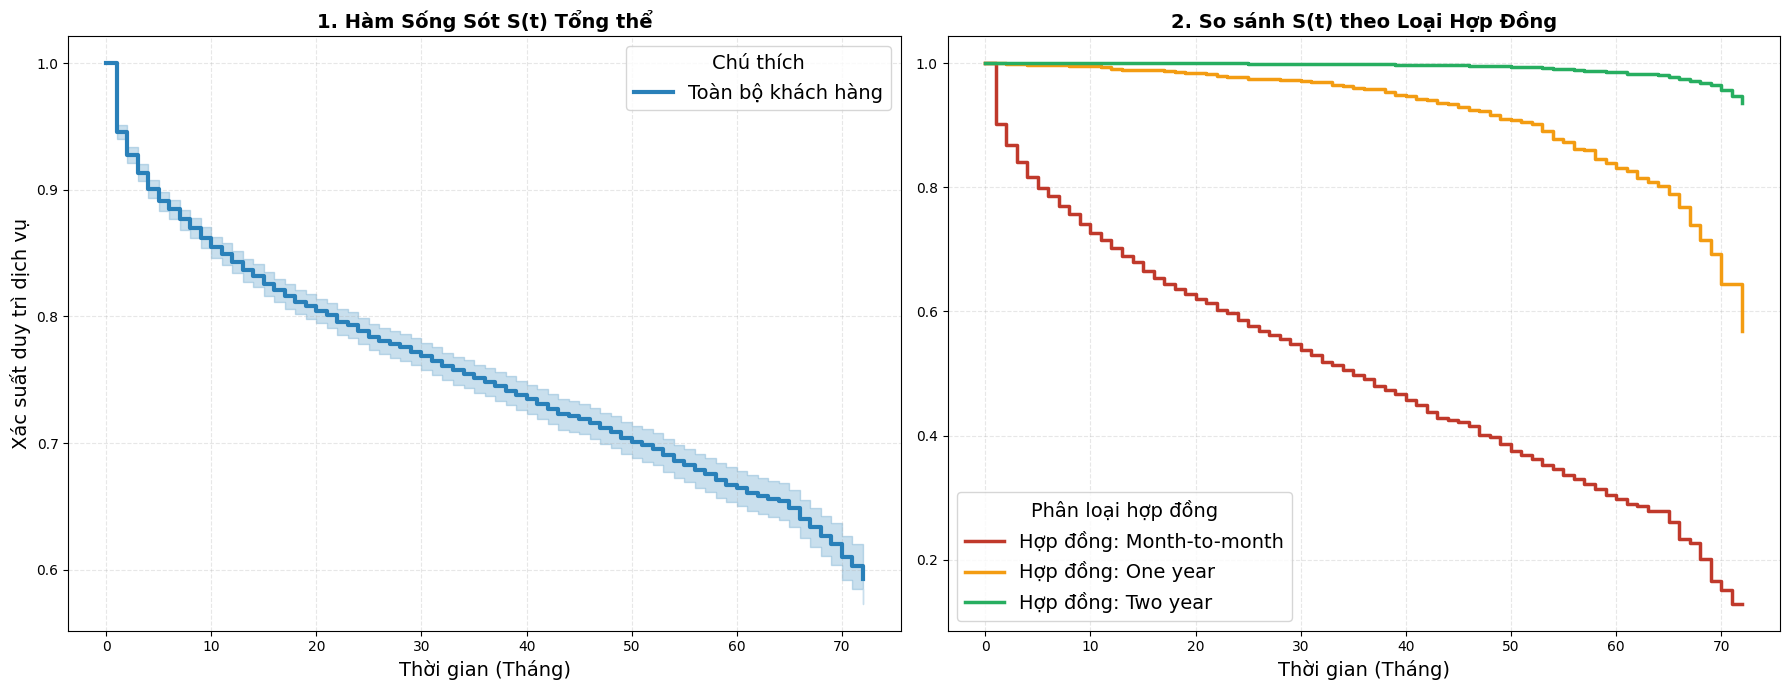


BẢNG TÓM TẮT MÔ HÌNH COX (COX SUMMARY)


<lifelines.CoxPHFitter: fitted with 7032 total observations, 5163 right-censored observations>
             duration col = 'T'
                event col = 'E'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7032
number of events observed = 1869
   partial log-likelihood = -14716.28
         time fit was run = 2026-02-13 14:56:27 UTC

---
                                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                 
Contract: One year                       -1.05      0.35      0.05           -1.16           -0.95                0.31                0.39
Contract: Two year                       -1.55      0.21      0.06           -1.66           -1.43                0.19                0.24
InternetService: DSL                     -0.24      0.78      0.04           -0.33           -0.16                0.72                0.86
InternetService: No                      -0.46      0.63      0.06           -0.59           -0.34                0.56                0.71
PaymentMethod: Mailed check               0.02      1.02      0.05           -0.09            0.12                0.91                1.13
PaymentMethod: Bank transfer (automatic) -0.53      0.59      0.05           -0.64           -0.43                0.53                0.65
PaymentMethod: Credit card (automatic)   -0.56      0.57      0.05           -0.66           -0.45                0.52                0.64
PaperlessBilling: No                     -0.20      0.82      0.04           -0.29           -0.11                0.75                0.89
Dependents: Yes                          -0.34      0.71      0.05           -0.44           -0.25                0.65                0.78

                                          cmp to      z      p  -log2(p)
covariate                                                               
Contract: One year                          0.00 -19.45 <0.005    277.46
Contract: Two year                          0.00 -26.38 <0.005    507.21
InternetService: DSL                        0.00  -5.44 <0.005     24.19
InternetService: No                         0.00  -7.27 <0.005     41.30
PaymentMethod: Mailed check                 0.00   0.29   0.77      0.37
PaymentMethod: Bank transfer (automatic)    0.00 -10.09 <0.005     77.18
PaymentMethod: Credit card (automatic)      0.00 -10.35 <0.005     80.96
PaperlessBilling: No                        0.00  -4.47 <0.005     17.00
Dependents: Yes                             0.00  -7.17 <0.005     40.31
---
Concordance = 0.82
Partial AIC = 29450.56
log-likelihood ratio test = 1873.52 on 9 df
-log2(p) of ll-ratio test = inf

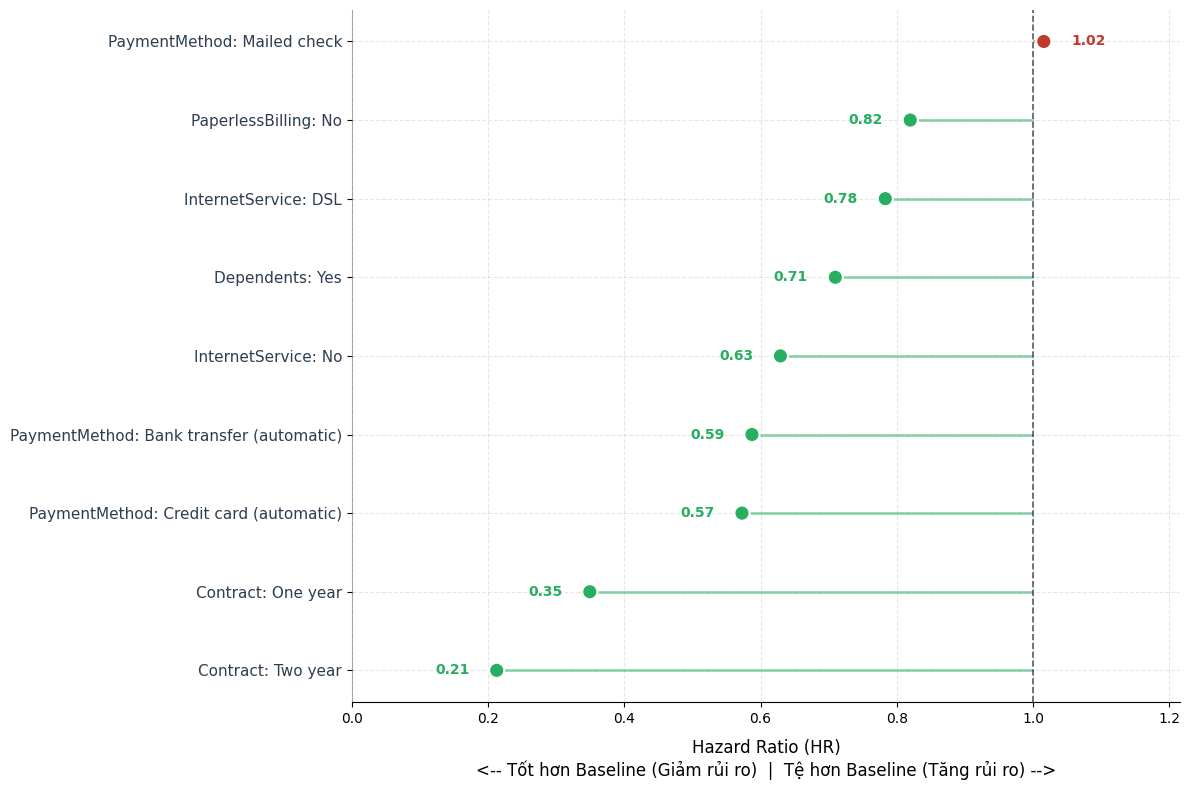

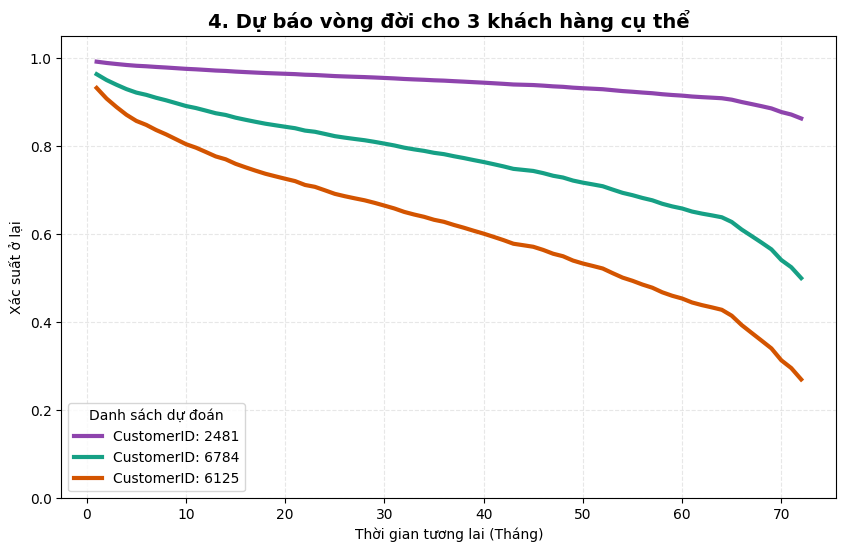

In [6]:
# ==========================================
# PHẦN 1: SETUP & CẤU HÌNH GIAO DIỆN
# ==========================================
!pip install -q lifelines
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
import warnings
warnings.filterwarnings('ignore')

# Cấu hình thẩm mỹ đồng bộ
plt.style.use('default')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (12, 8)

# Bảng màu ngữ nghĩa
COLORS = {
    'main': '#2980B9',      # Xanh dương (Tổng thể)
    'safe': '#27AE60',      # Xanh lá (An toàn)
    'risk': '#C0392B',      # Đỏ (Rủi ro)
    'warning': '#F39C12',   # Cam (Cảnh báo)
    'text': '#2C3E50'
}

# ==========================================
# PHẦN 2: DATA PROVISIONING & BASELINE SETUP
# ==========================================
# try:
#     df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
# except:
#     df = pd.read_csv('https://raw.githubusercontent.com/wafic/Telco-Customer-Churn/master/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df['E'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
df['T'] = df['tenure']
df = df[df['T'] > 0]

# Thiết lập Baseline (Nhóm tham chiếu HR=1.0) theo yêu cầu logic kinh doanh
# Chúng ta chọn các nhóm "Rủi ro nhất" làm chuẩn để thấy các nhóm khác "Tốt hơn" thế nào
df_model = df[['T', 'E', 'Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling', 'Dependents']].copy()

df_model['Contract'] = pd.Categorical(df_model['Contract'], categories=['Month-to-month', 'One year', 'Two year'])
df_model['InternetService'] = pd.Categorical(df_model['InternetService'], categories=['Fiber optic', 'DSL', 'No'])
df_model['PaymentMethod'] = pd.Categorical(df_model['PaymentMethod'], categories=['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'])
df_model['PaperlessBilling'] = pd.Categorical(df_model['PaperlessBilling'], categories=['Yes', 'No'])
df_model['Dependents'] = pd.Categorical(df_model['Dependents'], categories=['No', 'Yes'])

# One-hot encoding giữ nguyên Baseline
df_encoded = pd.get_dummies(df_model, drop_first=True)

# Làm sạch tên cột
df_encoded.columns = [col.replace('_', ': ') for col in df_encoded.columns]

print(">>> Tiền xử lý hoàn tất. Baseline đã được thiết lập tại nhóm rủi ro cao.")

# ==========================================
# PHẦN 3: TRỰC QUAN HÀM SỐNG SÓT (KM)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 3.1. Tổng thể
kmf = KaplanMeierFitter()
kmf.fit(df['T'], df['E'], label="Toàn bộ khách hàng")
kmf.plot_survival_function(ax=ax1, color=COLORS['main'], linewidth=3)
ax1.set_title('1. Hàm Sống Sót S(t) Tổng thể', fontsize=14, fontweight='bold')
ax1.set_xlabel('Thời gian (Tháng)', fontsize=14)
ax1.set_ylabel('Xác suất duy trì dịch vụ', fontsize=14)
ax1.legend(title="Chú thích", loc='best', fontsize=14, title_fontsize=14)

# 3.2. So sánh theo Loại Hợp đồng
contract_map = {'Month-to-month': COLORS['risk'], 'One year': COLORS['warning'], 'Two year': COLORS['safe']}
for c_type, c_color in contract_map.items():
    ix = df['Contract'] == c_type
    kmf.fit(df['T'][ix], df['E'][ix], label=f"Hợp đồng: {c_type}")
    kmf.plot_survival_function(ax=ax2, ci_show=False, color=c_color, linewidth=2.5)
ax2.set_title('2. So sánh S(t) theo Loại Hợp Đồng', fontsize=14, fontweight='bold')
ax2.set_xlabel('Thời gian (Tháng)', fontsize=14)
ax2.legend(title="Phân loại hợp đồng", loc='lower left', fontsize=14, title_fontsize=14)

plt.tight_layout()
plt.savefig('Fig_11_KM.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# PHẦN 4: COX REGRESSION & TRỰC QUAN HR (BẢN FIX ĐẸP)
# ==========================================
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_encoded, duration_col='T', event_col='E')

print("\n" + "="*50)
print("BẢNG TÓM TẮT MÔ HÌNH COX (COX SUMMARY)")
print("="*50)
cph.print_summary()

# Trích xuất và sắp xếp dữ liệu
summary = cph.summary.reset_index().sort_values('exp(coef)', ascending=True)
hr_values = summary['exp(coef)'].values
names = summary['covariate'].values
colors_hr = [COLORS['safe'] if x < 1 else COLORS['risk'] for x in hr_values]

plt.figure(figsize=(12, 8))

# 1. Vẽ đường Lollipop
plt.hlines(y=range(len(summary)), xmin=1, xmax=hr_values, color=colors_hr, alpha=0.5, linewidth=2)
plt.scatter(hr_values, range(len(summary)), color=colors_hr, s=120, zorder=3, edgecolors='white', linewidth=1.5)

# 2. Vẽ đường chuẩn Baseline HR=1
plt.axvline(x=1, color='#333333', linestyle='--', linewidth=1.2, alpha=0.8)

# 3. FIX HIỂN THỊ NHÃN SỐ (0.21, 1.02...)
for i, val in enumerate(hr_values):
    # Nếu HR < 1 (Vùng xanh): Đặt nhãn bên TRÁI dấu chấm
    if val < 1:
        plt.text(val - 0.04, i, f"{val:.2f}", 
                 va='center', ha='right', # Căn lề phải để đuôi số sát dấu chấm
                 fontweight='bold', color=COLORS['safe'], fontsize=10)
    # Nếu HR > 1 (Vùng đỏ): Đặt nhãn bên PHẢI dấu chấm
    else:
        plt.text(val + 0.04, i, f"{val:.2f}", 
                 va='center', ha='left', # Căn lề trái để đầu số sát dấu chấm
                 fontweight='bold', color=COLORS['risk'], fontsize=10)

# 4. TINH CHỈNH TRỤC VÀ KHOẢNG CÁCH
plt.yticks(range(len(summary)), names, fontsize=11, color='#2C3E50')

# Mở rộng trục X: bắt đầu từ 0 và kết thúc dư ra một chút so với max HR
plt.xlim(0, max(hr_values) + 0.2) 

# plt.title('3. Tác động của các biến so với Baseline rủi ro cao\n(Hazard Ratios)', 
#           fontsize=16, fontweight='bold', pad=20, color=COLORS['text'])
plt.xlabel('Hazard Ratio (HR)\n<-- Tốt hơn Baseline (Giảm rủi ro)  |  Tệ hơn Baseline (Tăng rủi ro) -->', 
           fontsize=12, labelpad=10)

# Bỏ khung viền thừa cho thoáng
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_alpha(0.3)

plt.tight_layout()
plt.savefig('Fig_12_Cox.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# PHẦN 5: DỰ BÁO CHO 3 KHÁCH HÀNG
# ==========================================
np.random.seed(42)
samples = df_encoded.sample(3)
surv_pred = cph.predict_survival_function(samples)

plt.figure(figsize=(10, 6))
pred_colors = ['#8E44AD', '#16A085', '#D35400']
for i, col in enumerate(surv_pred.columns):
    plt.plot(surv_pred.index, surv_pred[col], label=f"CustomerID: {col}", 
             color=pred_colors[i], linewidth=3)

plt.title('4. Dự báo vòng đời cho 3 khách hàng cụ thể', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian tương lai (Tháng)')
plt.ylabel('Xác suất ở lại')
plt.legend(title="Danh sách dự đoán", loc='lower left')
plt.ylim(0, 1.05)
plt.show()